In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


from importlib import reload
import kan
reload(kan)

from kan import KAN

## Multi-input, multi-output regression test

This test evaluates the tanh-basis KAN on a simple 2D regression task with two outputs.  
The inputs satisfy $x_1, x_2 \in (0,1]$, and the target functions are

$$
y_1 = \sin(4x_1) + 0.5x_2^2
$$

$$
y_2 = 0.3x_1^2 + \cos(3x_2)
$$

These targets are nonlinear but still additive across input coordinates, which matches the structure of a one-layer KAN:
$$
y_j = \sum_i \varphi_{ij}(x_i)
$$

In [2]:
x_min_test = 0
x_max_test = 1

In [3]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = x_min_test + x_max_test * torch.rand(n_train, 2)
x_test = x_min_test + x_max_test * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y1 = torch.sin(4.0 * x1) + 0.5 * x2**2
    y2 = 0.3 * x1**2 + torch.cos(3.0 * x2)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [4]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    num_basis=12,
    x_min=x_min_test,
    x_max=x_max_test,
    gamma_scale=3.0,
    debug=False,
)

optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

In [5]:
num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(f"Epoch {epoch:4d} | train loss = {loss.item():.6f} | test loss = {test_loss.item():.6f}")

Epoch    0 | train loss = 0.540077 | test loss = 0.462646
Epoch  250 | train loss = 0.000886 | test loss = 0.000541
Epoch  500 | train loss = 0.000757 | test loss = 0.000426
Epoch  750 | train loss = 0.000739 | test loss = 0.000414
Epoch 1000 | train loss = 0.000730 | test loss = 0.000408
Epoch 1250 | train loss = 0.000722 | test loss = 0.000403
Epoch 1500 | train loss = 0.000716 | test loss = 0.000400
Epoch 1750 | train loss = 0.000712 | test loss = 0.000398
Epoch 2000 | train loss = 0.000709 | test loss = 0.000396
Epoch 2250 | train loss = 0.000707 | test loss = 0.000396


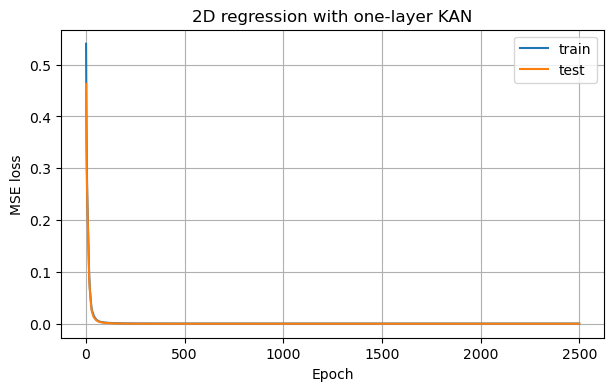

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer KAN")
plt.legend()
plt.grid(True)
plt.show()

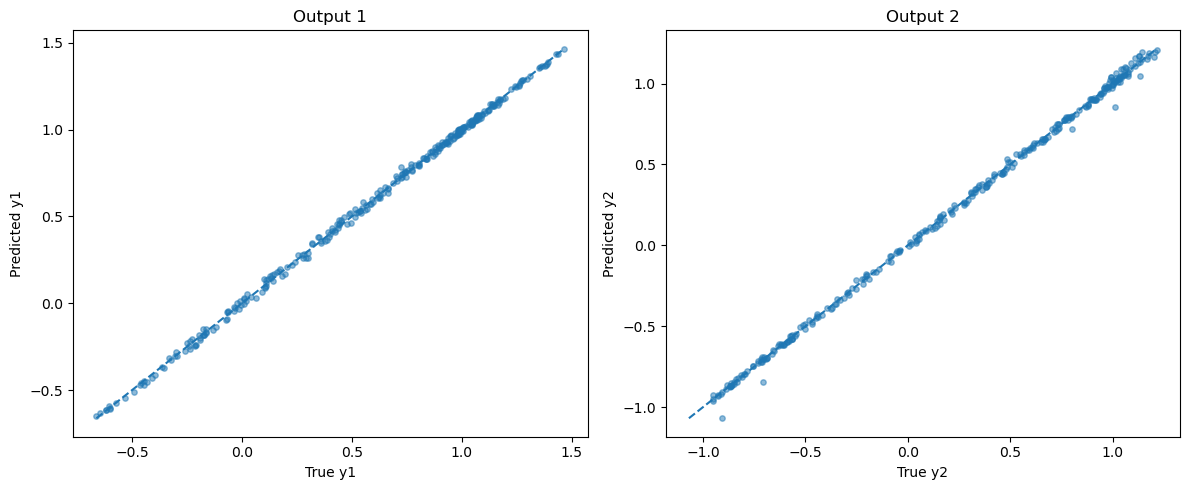

In [7]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

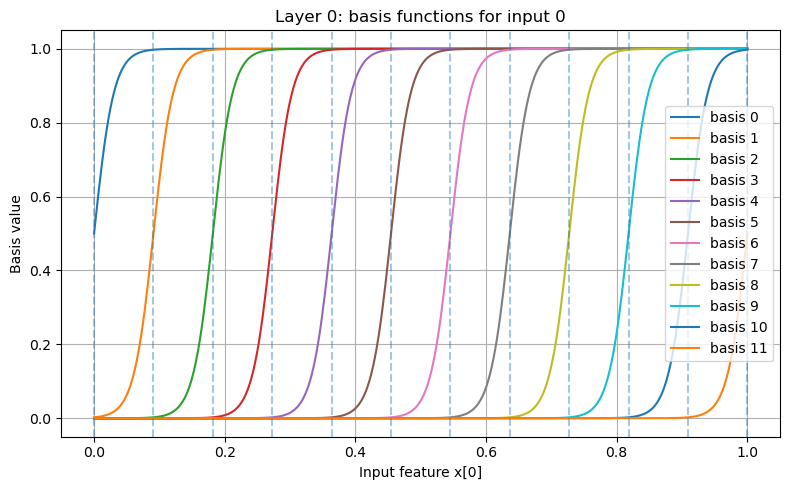

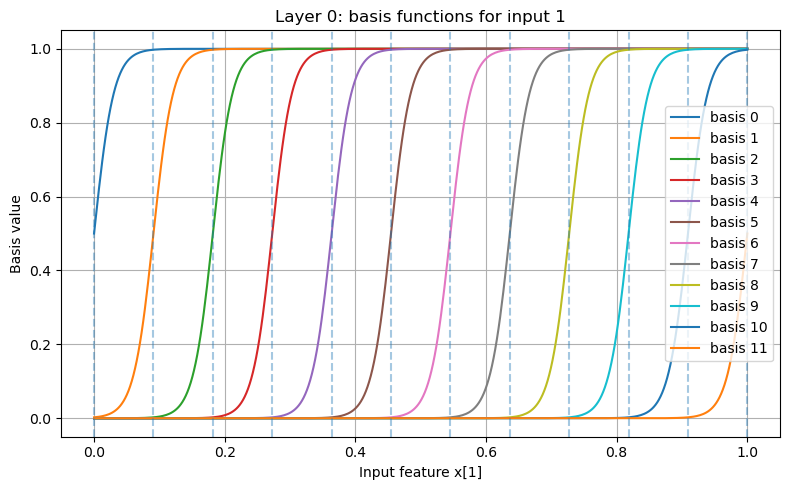

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


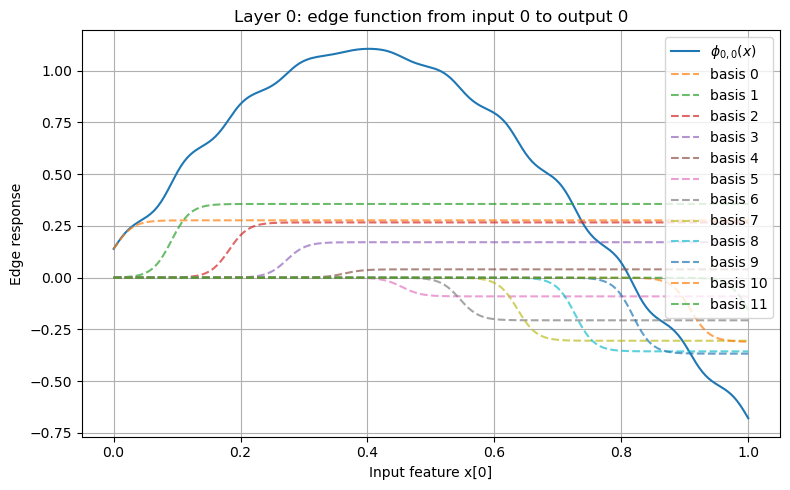

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


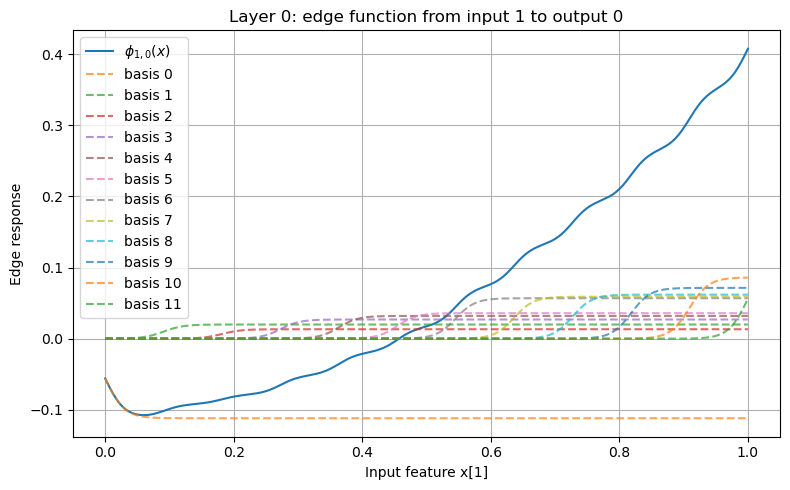

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


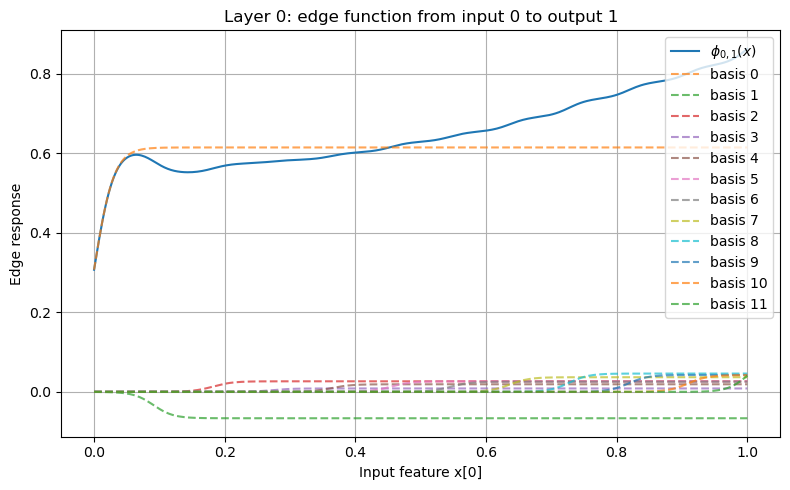

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


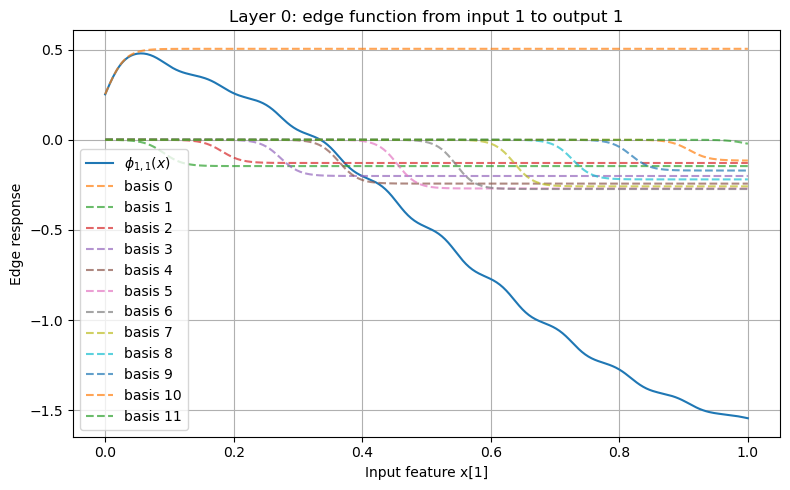

In [8]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test))
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test))

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True)

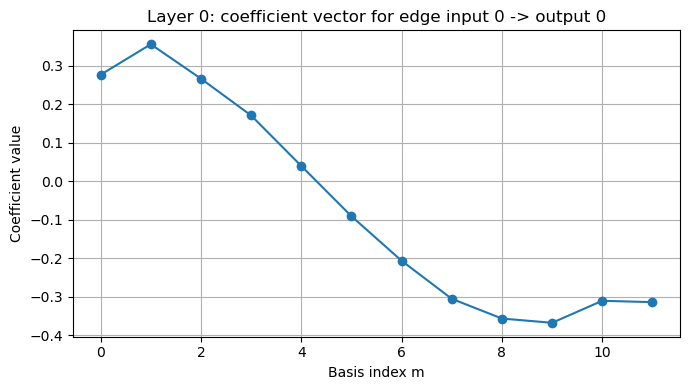

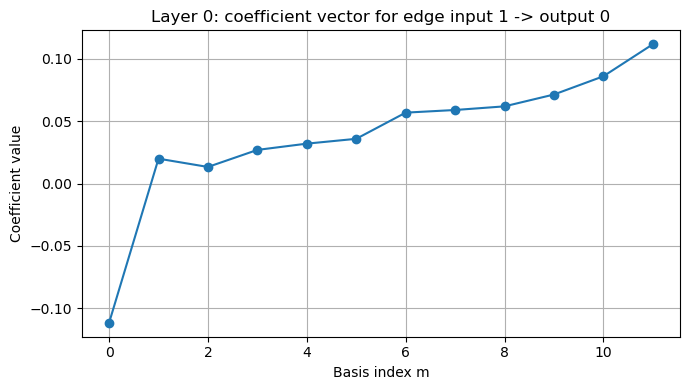

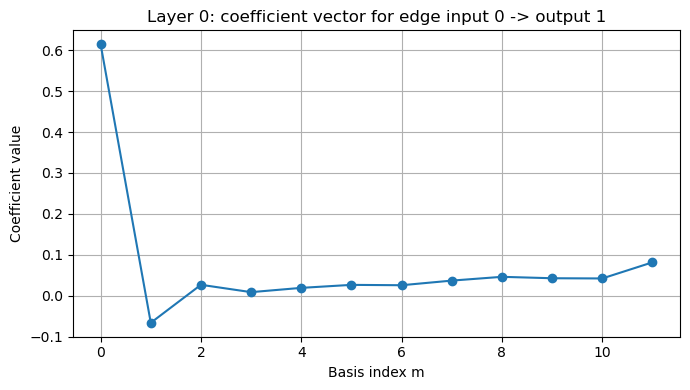

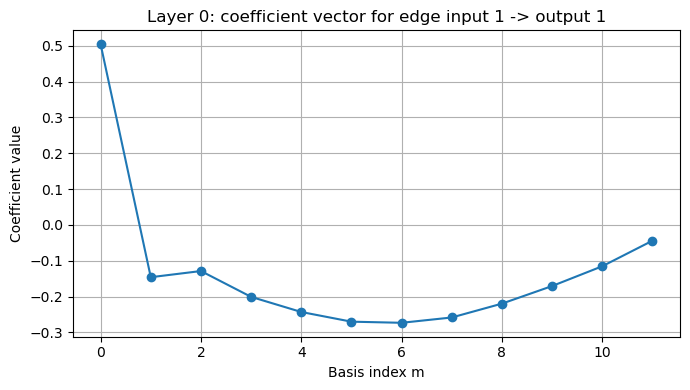

In [9]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1)

## Photonic activation

In [10]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

selected_indices = kan.select_equidistant_basis_indices(
    total_basis=b_coef.shape[0],
    num_selected=12,
)
#selected_indices = np.arange(12)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

Selected indices: [ 0  3  6  9 12 15 18 21 24 27 30 33]
Selected detunings: tensor([-5.0000e+10, -8.0000e+10, -1.1000e+11, -1.4000e+11, -1.7000e+11,
        -2.0000e+11, -2.3000e+11, -2.6000e+11, -2.9000e+11, -3.2000e+11,
        -3.5000e+11, -3.8000e+11])
Selected b_coef shape: torch.Size([12, 8])


In [11]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = x_min_test + x_max_test * torch.rand(n_train, 2)
x_test = x_min_test + x_max_test * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    x1n = x1 / x_max_test
    x2n = x2 / x_max_test

    y1 = torch.sin(4.0 * x1n) + 0.5 * x2n**2
    y2 = 0.3 * x1n**2 + torch.cos(3.0 * x2n)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [12]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    layer_type="photonic",
    b_coef_selected=b_coef_selected,
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    dropout_prob=0.0,
    normalize_basis=False,
    check_input_range=True,
    debug=False,
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device=device, dtype=torch.float64)

x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)

In [14]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train loss = {loss.item():.6f} | "
            f"test loss = {test_loss.item():.6f}"
        )

Epoch    0 | train loss = 0.532115 | test loss = 0.428187
Epoch  250 | train loss = 0.010296 | test loss = 0.009328
Epoch  500 | train loss = 0.010185 | test loss = 0.009215
Epoch  750 | train loss = 0.010168 | test loss = 0.009196
Epoch 1000 | train loss = 0.010163 | test loss = 0.009191
Epoch 1250 | train loss = 0.010159 | test loss = 0.009187
Epoch 1500 | train loss = 0.010155 | test loss = 0.009184
Epoch 1750 | train loss = 0.010151 | test loss = 0.009180
Epoch 2000 | train loss = 0.010148 | test loss = 0.009177
Epoch 2250 | train loss = 0.010144 | test loss = 0.009174


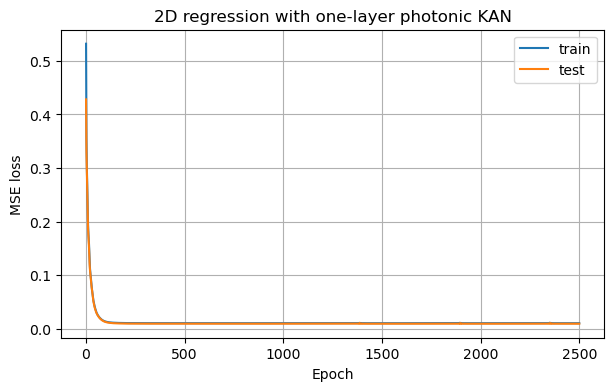

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer photonic KAN")
plt.legend()
plt.grid(True)
plt.show()

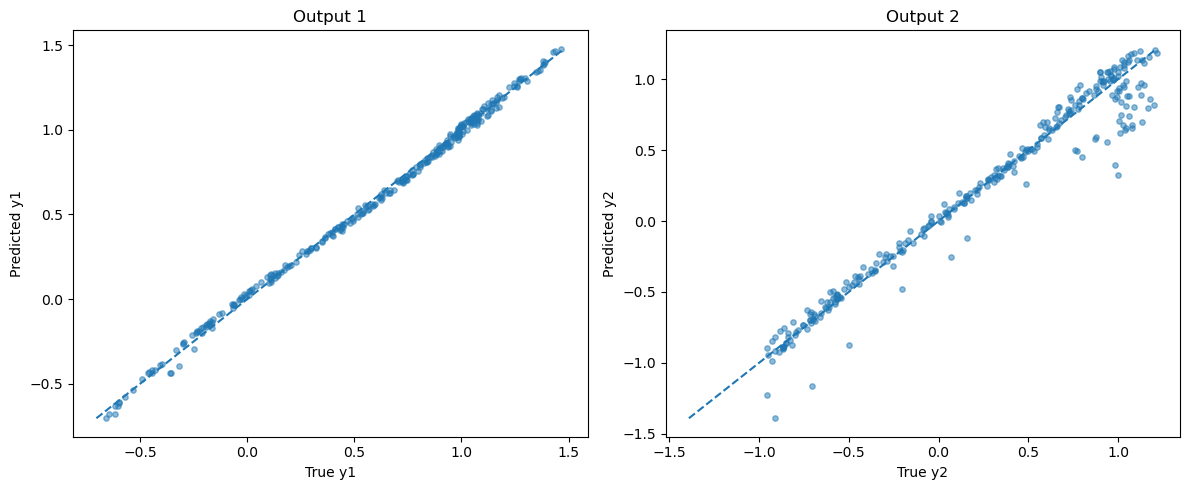

In [16]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

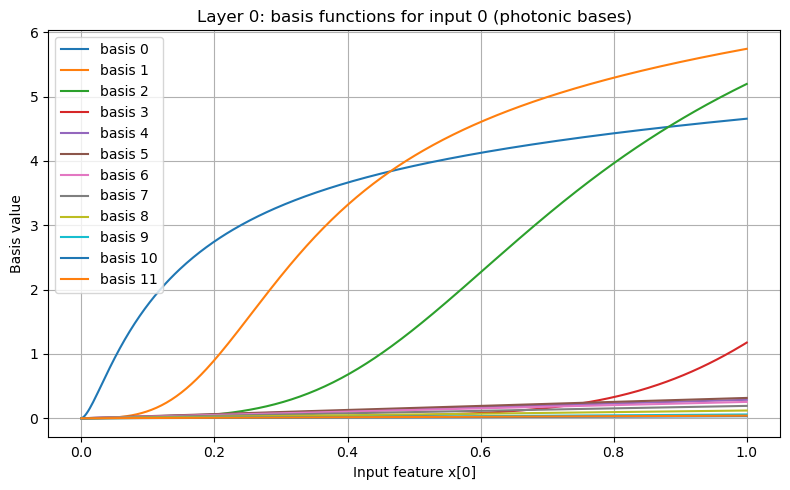

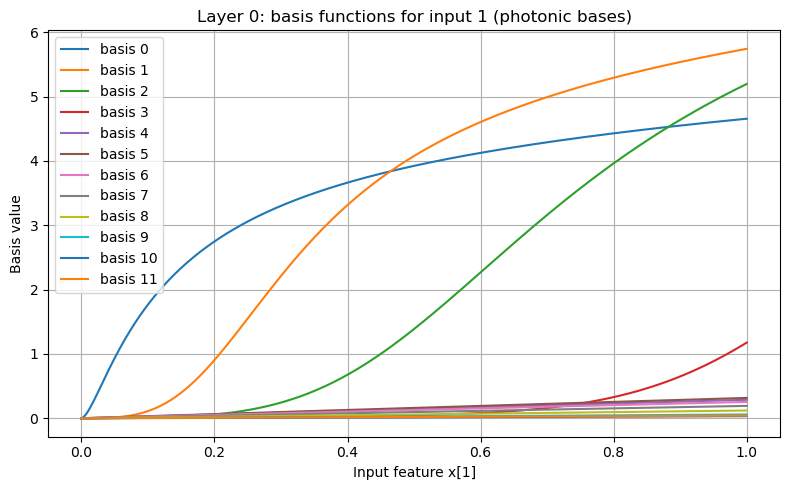

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


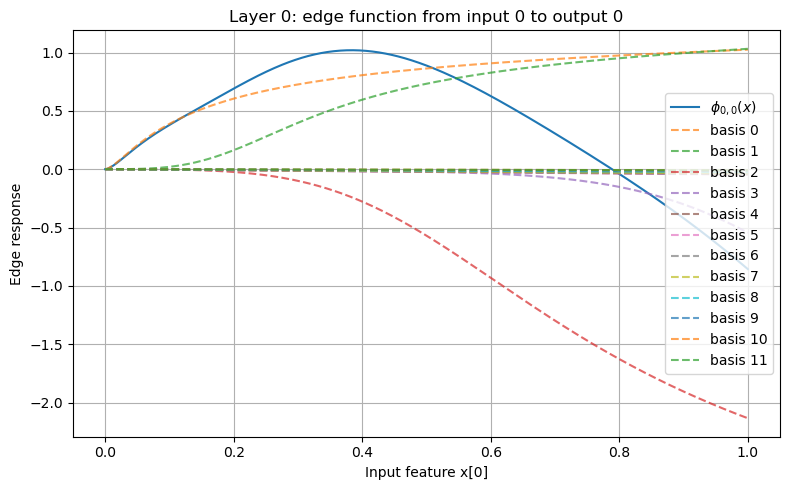

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


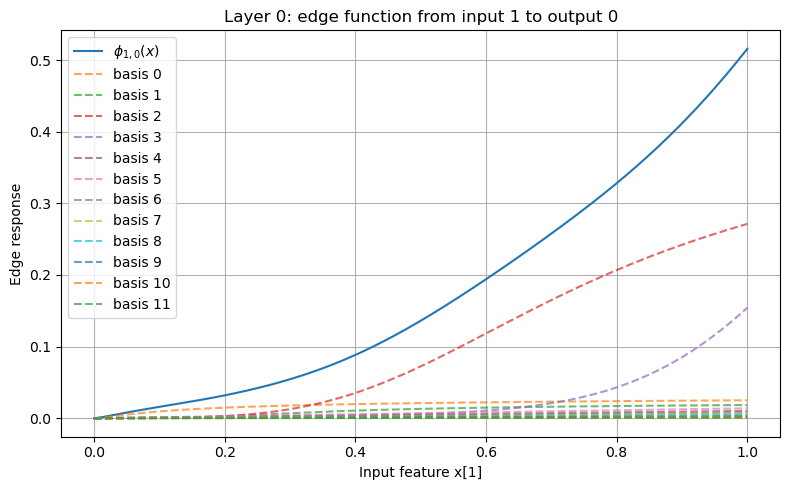

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


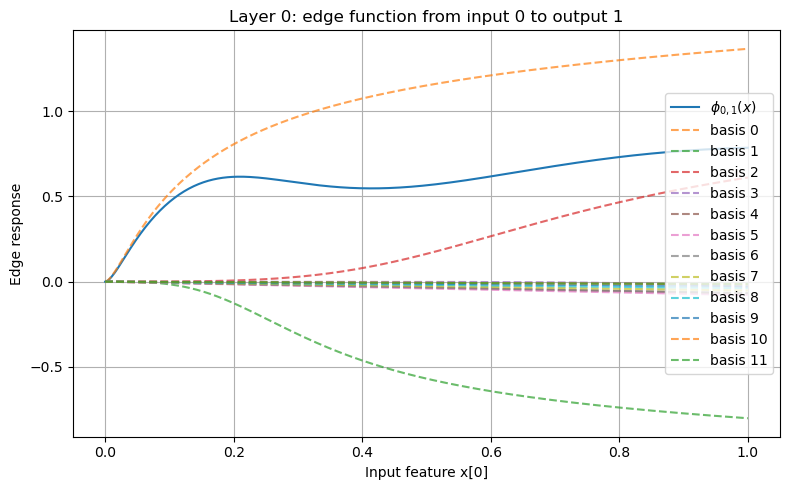

basis shape: torch.Size([400, 12])
basis finite: True
phi finite: True


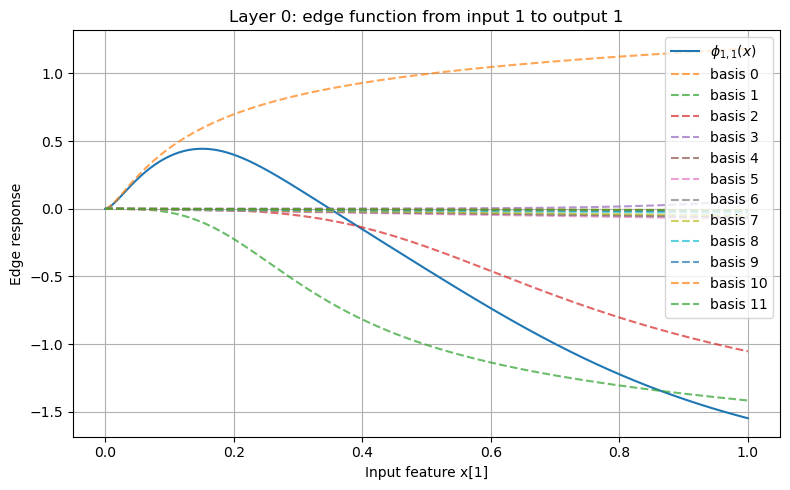

In [17]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test))
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test))

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True)

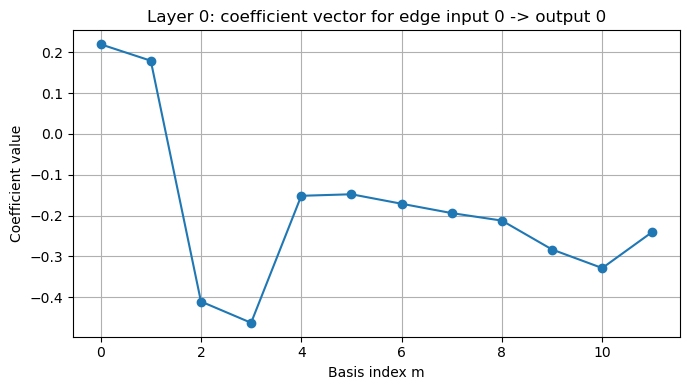

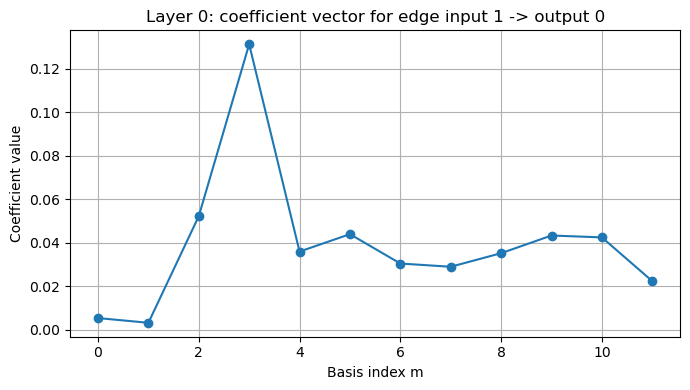

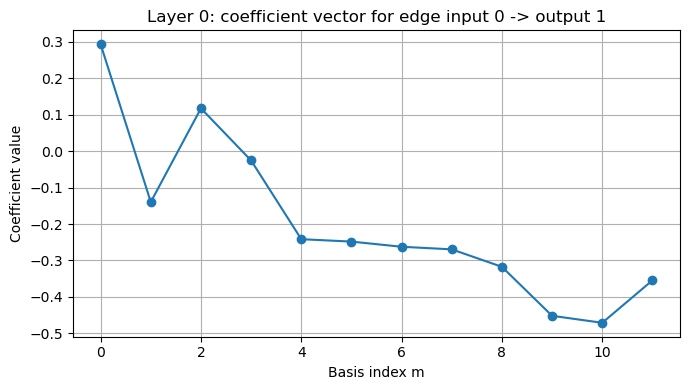

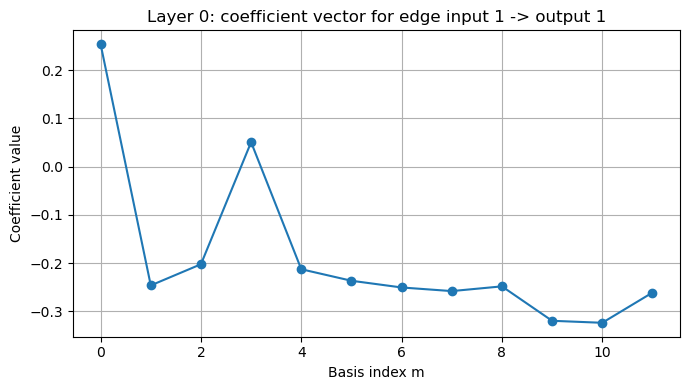

In [18]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1)

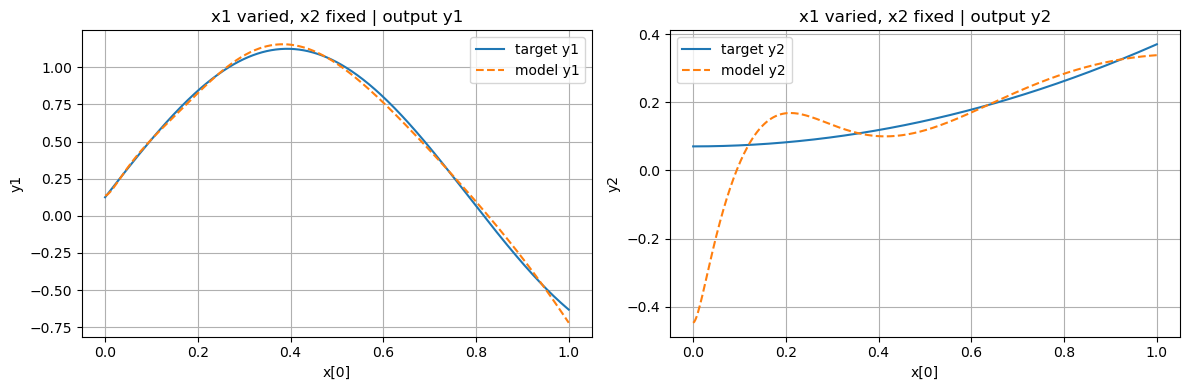

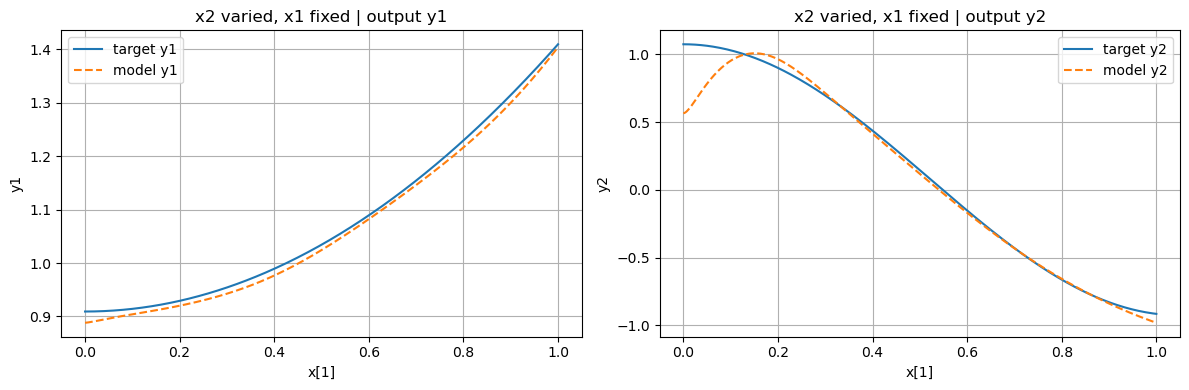

In [19]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[
        0.5 * (x_min_test + x_max_test),
        0.5 * (x_min_test + x_max_test),
    ],
)